# 30_plot_2d_maps.ipynb — Overview

This notebook visualizes 2D WRF fields: single-time snapshots (e.g., T2), animations across a period, wind barbs/vectors, divergence overlays, and precipitation intensity maps.

## Structure
- Setup: configure `domain_name`, `domain_id` (e.g., d01/d02/d03), `setting`, `varname`, `period_start/end`, `target_time` and the base `data_dir`.
- Load: discover and open multiple `wrfout_*` files as one dataset concatenated along Time.
- Process: convert units (e.g., K → °C for T2/TSK/T), compute derived fields (hourly precip, divergence), and select time slices.
- Plot/Export: static map plots, animated mp4, wind barbs, wind vectors with divergence, precipitation intensity; optionally save figures.

## Usage
1. Edit the settings in the first code cell: `domain_name`, `domain_id`, `setting`, `varname`, `period_*`, `target_time`.
2. Ensure WRF outputs exist under `sample_data/Run_WRF/<domain>/<setting>/` with names like `wrfout_d03_YYYY-MM-DD_HH:MM:SS`.
3. Run the cells top-to-bottom. To export animations, make sure `ffmpeg` is installed; add `plt.savefig(...)` where desired for static figures.
4. If loading many files is slow, narrow `period_start/end` or reduce the file set.

## Notes
- Packages: `xarray`, `numpy`, `matplotlib`, `cartopy` (plus `ffmpeg` for mp4 export).
- Coordinates/Time: expects `XLAT`, `XLONG`, `XTIME` in the WRF outputs. Typical variables include `T2`, `U10`, `V10`, `RAINC`, `RAINNC`.
- Example paths in this repo: `sample_data/Run_WRF/Bangkok/test/wrfout_d03_*`.

In [ ]:
import numpy as np
import xarray as xr
from datetime import datetime
from pathlib import Path
import os, glob

# Settings: Specify domain name, ID, and analysis period
domain_name = 'Bangkok'
domain_id = 'd03'  # Example: 'd01', 'd02', etc.
varname = 'T2'  # Variable name to plot
variables = ['Times', varname]
period_start = '2025-01-02 00:00:00'  # Analysis start time
period_end = '2025-01-07 23:00:00'    # Analysis end time
target_time = '2025-01-04 05:00:00'  # Time to plot (e.g., 'YYYY-MM-DD HH:MM:SS')
setting = 'test'

# Convert analysis period to numpy datetime64
period_start64 = np.datetime64(period_start)
period_end64 = np.datetime64(period_end)
target_time64 = np.datetime64(target_time)

# Define data directory and retrieve file list
data_dir = Path(f"../../sample_data/Run_WRF/{domain_name}/{setting}")
# data_dir = Path(os.environ.get('SIMULATION'), f"Run_WRF/{domain_name}/{setting}")

Instructions: Configure any variables used in the next cell, then run it. Keep paths consistent with your environment.

In [29]:
# ----------------------
# 2) Open WRF output(s)
# ----------------------

# Filter files based on the analysis period
def extract_start_time(path):
    try:
        timestamp = path.name.split(f"wrfout_{domain_id}_", 1)[1]
        return np.datetime64(datetime.strptime(timestamp, "%Y-%m-%d_%H:%M:%S"))
    except (IndexError, ValueError):
        return None

def open_wrf_outputs(wrf_glob):
    """Open multiple WRF output files as one dataset."""
    wrf_files = sorted(data_dir.glob(f"wrfout_{domain_id}_*"))
    print(f"Total files: {len(wrf_files)}")

    if not wrf_files:
        raise FileNotFoundError(f"No files matched pattern: {wrf_glob}")
    
    selected_files = [
        str(p) for p in wrf_files if (start_time := extract_start_time(p)) and period_start64 <= start_time <= period_end64
    ]
    file_list = selected_files or [str(p) for p in wrf_files]
    print(f"Using files: {file_list})")

    ds = xr.open_mfdataset(
        file_list, combine="nested", decode_times=True, concat_dim="Time"
    )
    return ds

da = open_wrf_outputs(data_dir)
da

Total files: 8
Using files: ['/mnt/work/yuasa/simulation/Run_WRF/Bangkok/test/wrfout_d03_2025-01-03_00:00:00', '/mnt/work/yuasa/simulation/Run_WRF/Bangkok/test/wrfout_d03_2025-01-04_00:00:00', '/mnt/work/yuasa/simulation/Run_WRF/Bangkok/test/wrfout_d03_2025-01-05_00:00:00'])


<xarray.Dataset> Size: 3GB
Dimensions:                (Time: 72, south_north: 99, west_east: 99,
                            bottom_top: 47, bottom_top_stag: 48,
                            soil_layers_stag: 4, west_east_stag: 100,
                            south_north_stag: 100, seed_dim_stag: 2)
Coordinates:
    XLAT                   (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    XLONG                  (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    XTIME                  (Time) datetime64[ns] 576B dask.array<chunksize=(24,), meta=np.ndarray>
    XLAT_U                 (Time, south_north, west_east_stag) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    XLONG_U                (Time, south_north, west_east_stag) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    XLAT_V                 (Time, south_north_stag, west_east) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    XLONG_V                (Time, south_north_stag, west_east) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag, seed_dim_stag
Data variables: (12/210)
    Times                  (Time) |S19 1kB dask.array<chunksize=(1,), meta=np.ndarray>
    LU_INDEX               (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    ZNU                    (Time, bottom_top) float32 14kB dask.array<chunksize=(1, 47), meta=np.ndarray>
    ZNW                    (Time, bottom_top_stag) float32 14kB dask.array<chunksize=(1, 48), meta=np.ndarray>
    ZS                     (Time, soil_layers_stag) float32 1kB dask.array<chunksize=(1, 4), meta=np.ndarray>
    DZS                    (Time, soil_layers_stag) float32 1kB dask.array<chunksize=(1, 4), meta=np.ndarray>
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    PC                     (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    LANDMASK               (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    LAKEMASK               (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    SST                    (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    SST_INPUT              (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.7.1 MODEL
    START_DATE:                      2025-01-01_00:00:00
    SIMULATION_START_DATE:           2025-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        100
    SOUTH-NORTH_GRID_DIMENSION:      100
    BOTTOM-TOP_GRID_DIMENSION:       48
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

Instructions: Configure any variables used in the next cell, then run it. Keep paths consistent with your environment.

Using time: 2025-01-04T05:00:00.000000000


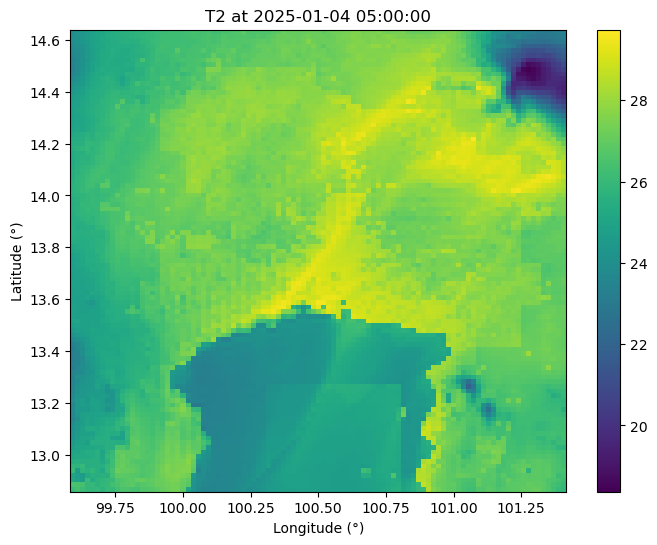

In [30]:
# Function to plot a 2D variable at a specific time
import matplotlib.pyplot as plt

def plot_variable_at_time(dataset, varname, target_time):
    """
    Plot a 2D variable from the dataset at the specified time.
    
    Parameters:
        dataset (xarray.Dataset): The dataset containing the variable.
        varname (str): The name of the variable to plot.
        target_time (str): The target time in 'YYYY-MM-DD HH:MM:SS' format.
    """

    if varname in ["T2", "T", "TSK"]:
        data_var = dataset[varname] - 273.15  # K → °C
    else:
        data_var = dataset[varname]

    lat = dataset["XLAT"].isel(Time=0).values
    lon = dataset["XLONG"].isel(Time=0).values

    # Find the index of the target time (exact match or closest)
    times = dataset['XTIME'].values
    time_index = np.where(times == target_time64)[0][0]
    print(f'Using time: {str(times[time_index])}')
    
    # Plot the variable
    plt.figure(figsize=(8, 6))
    data_var.isel(Time=time_index).plot(
        cbar_kwargs={'label': data_var.attrs.get('units', '')},
        x="XLONG", y="XLAT"  # Use longitude and latitude as labels
    )
    plt.title(f'{varname} at {target_time}')
    plt.xlabel("Longitude (°)")
    plt.ylabel("Latitude (°)")
    plt.show()

# Example usage
plot_variable_at_time(da, varname, target_time)

Instructions: Configure any variables used in the next cell, then run it. Keep paths consistent with your environment.

In [31]:
# Function to create an animation of a 2D variable over a specified period
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_variable(dataset, varname, period_start, period_end, interval=200):
    """
    Create an animation of a 2D variable over the specified period.

    Parameters:
        dataset (xarray.Dataset): The dataset containing the variable.
        varname (str): The name of the variable to animate.
        period_start (str): Start time of the period in 'YYYY-MM-DD HH:MM:SS' format.
        period_end (str): End time of the period in 'YYYY-MM-DD HH:MM:SS' format.
        interval (int): Interval between frames in milliseconds.
    """
    if varname in ["T2", "T", "TSK"]:
        data_var = dataset[varname] - 273.15  # K → °C
    else:
        data_var = dataset[varname]

    # Filter times within the specified period
    times = dataset['XTIME'].values
    time_indices = np.where((times >= np.datetime64(period_start)) & (times <= np.datetime64(period_end)))[0]
    if len(time_indices) == 0:
        raise ValueError("No data available for the specified period.")

    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(8, 6))
    cbar = None

    def update(frame):
        nonlocal cbar
        ax.clear()
        data = data_var.isel(Time=frame)
        im = data.plot(ax=ax, add_colorbar=False, x="XLONG", y="XLAT")  # Use longitude and latitude as labels
        if cbar is None:
            cbar = plt.colorbar(im, ax=ax, label=data_var.attrs.get('units', ''))
        ax.set_title(f'{varname} at {str(times[frame])}')
        ax.set_xlabel("Longitude (°)")
        ax.set_ylabel("Latitude (°)")
        return im,

    ani = FuncAnimation(fig, update, frames=time_indices, interval=interval, blit=False)
    plt.close(fig)  # Prevent displaying the static plot
    return ani

# Example usage
period_start, period_end = '2025-01-04 00:00:00', '2025-01-05 23:00:00'
animation = animate_variable(da, varname, period_start, period_end)
animation.save(f"{varname}_animation.mp4", writer="ffmpeg")
# HTML(animation.to_jshtml())

/tmp/ipykernel_591239/951904752.py:37: UserWarning: Adding colorbar to a different Figure <Figure size 800x600 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax, label=data_var.attrs.get('units', ''))


<Figure size 640x480 with 0 Axes>

Instructions: Configure any variables used in the next cell, then run it. Keep paths consistent with your environment.

Using time: 2025-01-04T05:00:00.000000000


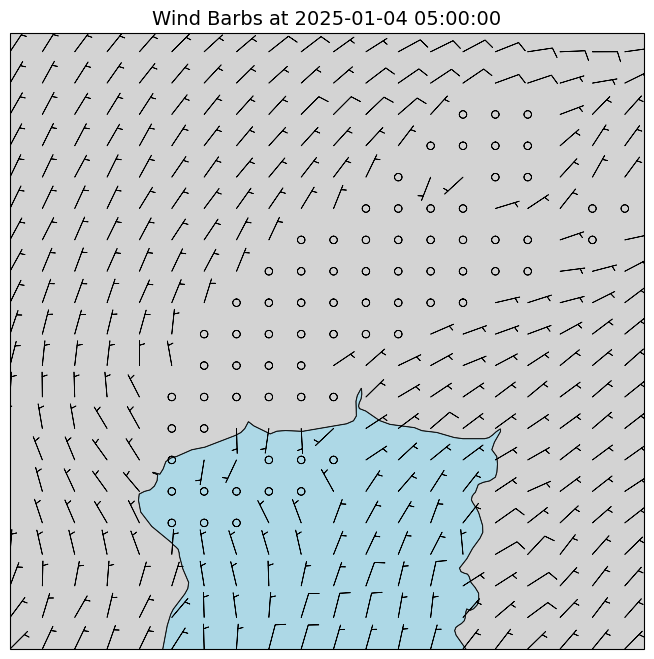

In [32]:
# Function to plot wind barbs
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Function to plot wind barbs with a map background
def plot_wind_barbs(dataset, u_var, v_var, target_time, skip=5):
    """
    Plot wind barbs from the dataset at the specified time.

    Parameters:
        dataset (xarray.Dataset): The dataset containing the wind components.
        u_var (str): The name of the U wind component variable.
        v_var (str): The name of the V wind component variable.
        target_time (str): The target time in 'YYYY-MM-DD HH:MM:SS' format.
        skip (int): Step size for skipping grid points (for clarity).
    """
    lat = dataset["XLAT"].isel(Time=0).values
    lon = dataset["XLONG"].isel(Time=0).values

    # Find the index of the target time (exact match or closest)
    times = dataset['XTIME'].values
    time_index = np.where(times == target_time64)[0][0]
    print(f'Using time: {str(times[time_index])}')

    u = dataset[u_var].isel(Time=time_index).values
    v = dataset[v_var].isel(Time=time_index).values

    # Plot wind barbs with a map background
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

    # Plot wind barbs
    barbs = ax.barbs(
        lon[::skip, ::skip], lat[::skip, ::skip],
        u[::skip, ::skip], v[::skip, ::skip],
        length=6, linewidth=0.6, fill_empty=False, transform=ccrs.PlateCarree()
    )

    # Add title and labels
    ax.set_title(f"Wind Barbs at {target_time}", fontsize=14)
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")

    plt.show()

# Example usage
plot_wind_barbs(da, "U10", "V10", target_time, skip=5)

Instructions: Configure any variables used in the next cell, then run it. Keep paths consistent with your environment.

Using time: 2025-01-04T05:00:00.000000000


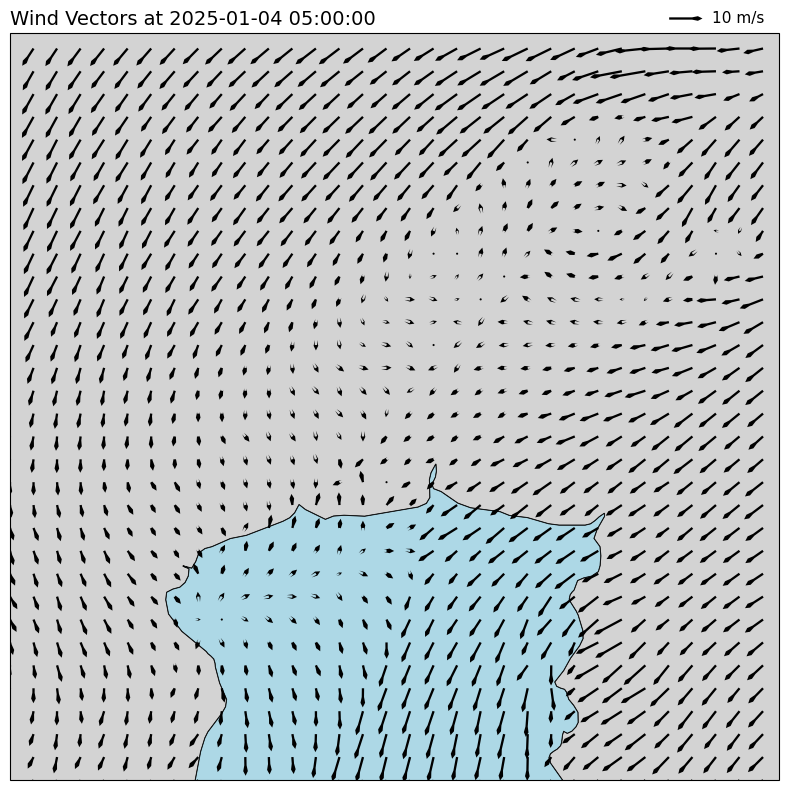

In [33]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm

# Function to plot wind vectors
def plot_wind_vectors_and_divergence(dataset, u_var, v_var, target_time, skip=5):
    """
    Plot wind vectors using arrows and overlay divergence/convergence contours.

    Parameters:
        dataset (xarray.Dataset): The dataset containing the wind components.
        u_var (str): The name of the U wind component variable.
        v_var (str): The name of the V wind component variable.
        target_time (str): The target time in 'YYYY-MM-DD HH:MM:SS' format.
        skip (int): Step size for skipping grid points (for clarity).
    """
    lat = dataset["XLAT"].isel(Time=0).values
    lon = dataset["XLONG"].isel(Time=0).values

    # Find the index of the target time (exact match or closest)
    times = dataset['XTIME'].values
    time_index = np.where(times == target_time64)[0][0]
    print(f'Using time: {str(times[time_index])}')

    u = dataset[u_var].isel(Time=time_index).values
    v = dataset[v_var].isel(Time=time_index).values

    # Plot wind vectors and divergence/convergence contours
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

    # Plot wind vectors
    quiver = ax.quiver(
        lon[::skip, ::skip], lat[::skip, ::skip],
        u[::skip, ::skip], v[::skip, ::skip],
        scale=30, scale_units="inches",
        width=0.003, headwidth=2, headlength=2,
        transform=ccrs.PlateCarree(), color="black"
    )

    # Title and labels
    ax.set_title(f"Wind Vectors at {target_time}", fontsize=14, loc='left')
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")

    # Adjust layout to prevent overlap with title
    fig.subplots_adjust(top=0.90)

    # Add quiver key (placed above plot, avoiding overlap with title)
    ax.quiverkey(
        quiver, 0.90, 1.02, 10, "10 m/s",
        labelpos="E", coordinates="axes",
        fontproperties={"size": 11}, color="black"
    )

    plt.tight_layout()
    plt.show()

# Example usage 
plot_wind_vectors_and_divergence(da, "U10", "V10", target_time, skip=3)

Instructions: Configure any variables used in the next cell, then run it. Keep paths consistent with your environment.

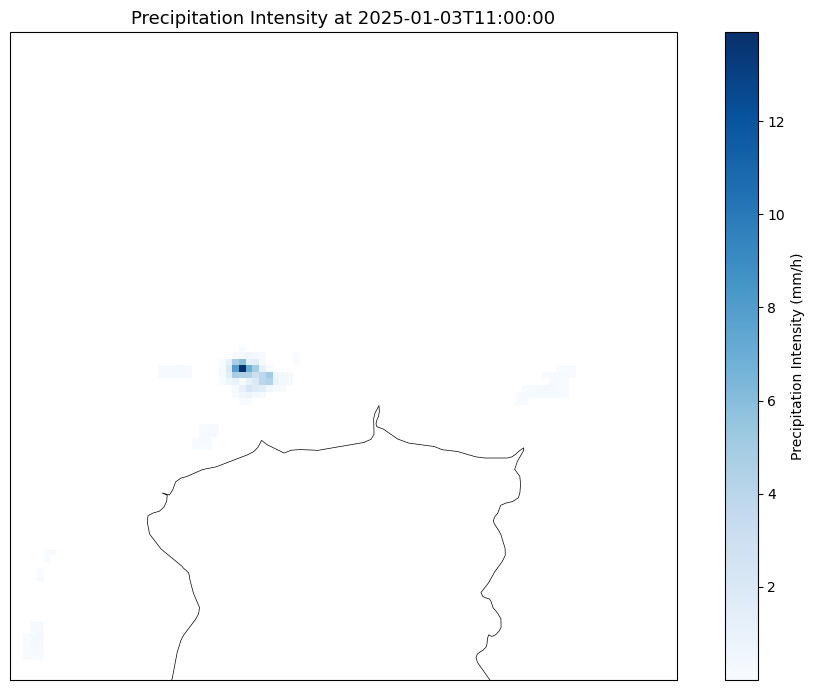

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def plot_precip_intensity_at_time(dataset, target_time64):
    """
    Plot precipitation intensity (RAINC + RAINNC) at a specific time.

    Parameters:
        dataset (xarray.Dataset): WRF dataset containing RAINC, RAINNC, XLAT, XLONG.
        target_time64 (numpy.datetime64): Target time to visualize.
    """
    # Find index of the target time
    times = dataset["XTIME"].values
    idx = np.where(times == target_time64)[0][0]
    prev_idx = idx - 1
    if prev_idx < 0:
        raise ValueError("Target time must be at least one step after simulation start.")

    # Compute hourly precipitation (difference between current and previous time)
    # rainc = dataset["PREC_ACC_C"].isel(Time=idx)
    # rainnc = dataset["PREC_ACC_NC"].isel(Time=idx)
    rainc = dataset["RAINC"].isel(Time=idx) - dataset["RAINC"].isel(Time=prev_idx)
    rainnc = dataset["RAINNC"].isel(Time=idx) - dataset["RAINNC"].isel(Time=prev_idx)
    rain_total = (rainc + rainnc) * 1000
    # Mask zero values (set to NaN so they won't be plotted)
    rain_total = rain_total.where(rain_total != 0, np.nan)

    # Extract coordinates
    lat = dataset["XLAT"].isel(Time=0)
    lon = dataset["XLONG"].isel(Time=0)

    # Plot figure
    fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={"projection": ccrs.PlateCarree()})
    pcm = ax.pcolormesh(lon, lat, rain_total, cmap="Blues", shading="auto", transform=ccrs.PlateCarree())
    cbar = plt.colorbar(pcm, ax=ax, label="Precipitation Intensity (mm/h)")

    # Map features
    ax.coastlines(linewidth=0.5)
    ax.set_title(f"Precipitation Intensity at {str(target_time64)}", fontsize=13)
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")

    plt.tight_layout()
    plt.show()

# Example usage
target_time64 = np.datetime64('2025-01-04 10:00:00')
plot_precip_intensity_at_time(da, target_time64)

Instructions: Configure any variables used in the next cell, then run it. Keep paths consistent with your environment.

Using time: 2025-01-03T11:00:00.000000000
dx shape: (99, 99), dy shape: (99, 99)


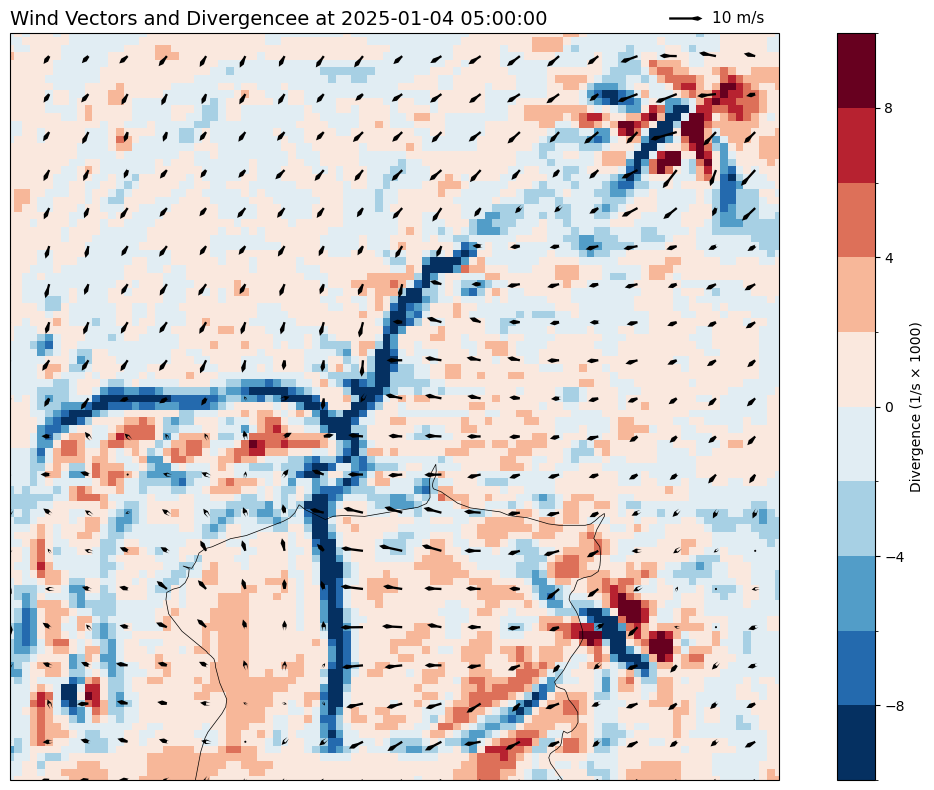

In [35]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm

# Function to plot wind vectors and divergence/convergence contours
def plot_wind_vectors_and_divergence(dataset, u_var, v_var, target_time, skip=5):
    """
    Plot wind vectors using arrows and overlay divergence/convergence contours.

    Parameters:
        dataset (xarray.Dataset): The dataset containing the wind components.
        u_var (str): The name of the U wind component variable.
        v_var (str): The name of the V wind component variable.
        target_time (str): The target time in 'YYYY-MM-DD HH:MM:SS' format.
        skip (int): Step size for skipping grid points (for clarity).
    """
    lat = dataset["XLAT"].isel(Time=0).values
    lon = dataset["XLONG"].isel(Time=0).values

    # Find the index of the target time (exact match or closest)
    times = dataset['XTIME'].values
    time_index = np.where(times == target_time64)[0][0]
    print(f'Using time: {str(times[time_index])}')

    u = dataset[u_var].isel(Time=time_index).values
    v = dataset[v_var].isel(Time=time_index).values

    # Compute divergence
    dx = dataset["DX2D"].isel(Time=0).values
    print(f"dx shape: {dx.shape}, dy shape: {dx.shape}")
    dudx = np.gradient(u, axis=1) / dx
    dvdy = np.gradient(v, axis=0) / dx
    divergence = (dudx + dvdy) * 10000

    # Plot wind vectors and divergence/convergence contours
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

    # Plot divergence/convergence as discrete color bands
    levels = np.arange(-10, 11, 2)  # Discrete levels from -10 to 10 with a step of 2
    pcm = ax.pcolormesh(
        lon, lat, divergence, cmap="RdBu_r", norm=BoundaryNorm(levels, ncolors=256), shading="auto", transform=ccrs.PlateCarree()
    )
    # Plot wind vectors
    quiver = ax.quiver(
        lon[::skip, ::skip], lat[::skip, ::skip],
        u[::skip, ::skip], v[::skip, ::skip],
        scale=30, scale_units="inches",
        width=0.003, headwidth=2, headlength=2,
        transform=ccrs.PlateCarree(), color="black"
    )

    # Title and labels
    ax.set_title(f"Wind Vectors and Divergencee at {target_time}", fontsize=14, loc='left')
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")

    # plt.colorbar(contour, ax=ax, orientation="vertical", label="Divergence (1/s)")

    # Adjust layout to prevent overlap with title
    fig.subplots_adjust(top=0.90)

    # Add quiver key (placed above plot, avoiding overlap with title)
    ax.quiverkey(
        quiver, 0.90, 1.02, 10, "10 m/s",
        labelpos="E", coordinates="axes",
        fontproperties={"size": 11}, color="black"
    )

    # Add a colorbar for the divergence field
    plt.colorbar(pcm, ax=ax, orientation="vertical", label="Divergence (1/s × 1000)")
    plt.tight_layout()
    plt.show()

# Example usage 
plot_wind_vectors_and_divergence(da, "U10", "V10", target_time, skip=5)

Instructions: Configure any variables used in the next cell, then run it. Keep paths consistent with your environment.